<center>

<h2>Phase 2: Generative AI Integration</h2>

<p><b>Phishing URL Detection Project</b></p>

<p>
This notebook integrates Generative AI into the phishing URL detection system
developed in Phase 1. The goal is to use a large language model to generate
clear, user-friendly explanations of phishing predictions, turning raw model
output into actionable security advice.
</p>

<br>

<h2>Notebook Overview</h2>

<table>
<tr>
<th>No.</th>
<th>Section</th>
</tr>
<tr><td>1</td><td>Generative AI Model Selection and Setup</td></tr>
<tr><td>2</td><td>Prompt Template Design Documentation</td></tr>
<tr><td>3</td><td>Implementation and API Integration Code</td></tr>
<tr><td>4</td><td>Testing Framework and Output Comparison</td></tr>
<tr><td>5</td><td>Analysis: Qualitative and Quantitative Results</td></tr>
<tr><td>6</td><td>Best Prompt Selection and Justification</td></tr>
<tr><td>7</td><td>Integration Plan for Final System</td></tr>
<tr><td>8</td><td>Ethical Considerations and Limitations</td></tr>
</table>

</center>

<center>
<h2>1. Generative AI Model Selection and Setup</h2>
</center>

---

### 1.1 Model Choice

For this project, we selected Google Gemini 2.5 Flash accessed through the Google AI Studio API.

| Criterion | Justification |
|-----------|--------------|
| **Cost** | Completely free through Google AI Studio with no credit card required |
| **Capability** | Strong instruction-following and structured output generation suitable for producing consistent explanations |
| **Rate Limits** | The free tier allows up to 10 requests per minute and 250 requests per day, which is sufficient for testing and evaluation |
| **API Compatibility** | The API follows an OpenAI-compatible format, making integration straightforward |

### 1.2 Alternative Models Considered

- OpenAI GPT-4o-mini: Strong capability but requires a paid API key.
- LLaMA 3 (Meta via Groq): Free tier available with fast inference, but lower rate limits.
- Hugging Face Inference API: Free for models under 10GB, but the quality of smaller open-source models is lower than Gemini for structured prompt engineering.

### 1.3 Integration Approach

The model receives structured input containing the URL, extracted features, the supervised model's prediction, and prediction confidence. It then generates an explanation of why the URL was flagged as phishing or classified as legitimate.

### 1.4 Environment Setup

In [ ]:
# Install textstat for readability metrics
!pip install textstat -q

In [ ]:
# Install the Google Generative AI Python client
!pip install google-generativeai -q

In [ ]:
import google.generativeai as genai
import os
import json
import time
import re
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Load API key securely from Colab secrets
# Setup steps:
#   1. Go to https://aistudio.google.com/apikey
#   2. Create a free API key
#   3. In Colab, click the key icon in the left sidebar
#   4. Add a secret named "GEMINI_API_KEY" with your key value

from google.colab import userdata
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

genai.configure(api_key=GEMINI_API_KEY)

model = genai.GenerativeModel("gemini-2.5-flash")
print("Gemini 2.5 Flash model initialized successfully.")

Gemini 2.5 Flash model initialized successfully.


The API key is loaded from Colab's secure secret manager (`userdata`), which prevents the key from appearing in the notebook output or being pushed to GitHub.

### 1.5 Load Phase 1 Artifacts

The trained supervised model and the fitted scaler from Phase 1 are loaded here. The saved model file is used directly instead of retraining, ensuring that predictions match the Phase 1 evaluation results exactly.

In [ ]:
import textstat # Flesch-Kincaid readability scoring
import joblib # load saved sklearn objects
from urllib.parse import urlparse # URL parsing for feature extraction
from google.colab import drive

# Mount Google Drive to access Phase 1 saved artifacts
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the fitted scaler from Phase 1 to prevent data leakage.
# We reuse it here for consistent scaling.
scaler = joblib.load("/content/drive/MyDrive/phishing_scaler.pkl")

# Load the trained model from Phase 1
lr_model = joblib.load("/content/drive/MyDrive/logistic_regression.pkl")

# Extract the feature names the scaler and model expect
SCALER_FEATURES = list(scaler.feature_names_in_)
MODEL_FEATURES  = list(lr_model.feature_names_in_)

print("Phase 1 artifacts loaded.")
print("Scaler features:", SCALER_FEATURES)
print("Model features: ", MODEL_FEATURES)

Phase 1 artifacts loaded.
Scaler features: ['URLLength', 'DomainLength', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'NoOfQMarkInURL', 'IsHTTPS', 'NoOfURLRedirect', 'NoOfSelfRedirect']
Model features:  ['URLLength', 'DomainLength', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'NoOfQMarkInURL', 'IsHTTPS', 'NoOfURLRedirect', 'NoOfSelfRedirect']


The scaler and model are loaded from Google Drive where they were saved at the end of Phase 1. `SCALER_FEATURES` and `MODEL_FEATURES` store the exact column names each object expects, ensuring that feature extraction produces vectors in the correct order.

In [ ]:
# Feature extraction pipeline

def extract_features(url):
    """Extract URL-based lexical features from a raw URL string.

    Parameters
    ----------
    url : str
        The full URL to analyze (e.g., "http://example.com/path").

    Returns
    -------
    dict
        Dictionary mapping feature names to their computed values.
        Only features expected by the scaler are returned.
    """
    parsed = urlparse(url)
    domain = parsed.netloc
    tld    = domain.split(".")[-1] if "." in domain else ""
    parts  = domain.split(".")
    path   = parsed.path

    # Compute all candidate features from the URL string
    all_feats = {
        "URLLength"           : len(url),
        "DomainLength"        : len(domain),
        "TLDLength"           : len(tld),
        "NoOfSubDomain"       : max(len(parts) - 2, 0),
        "NoOfObfuscatedChar"  : len(re.findall(r"%[0-9a-fA-F]{2}", url)),
        "NoOfURLRedirect"     : max(len(re.findall(r"https?://", url)) - 1, 0),
        "NoOfSelfRedirect"    : max(url.count(domain) - 1, 0),
        "NoOfQMarkInURL"      : url.count("?"),
        "IsHTTPS"             : 1 if parsed.scheme == "https" else 0,
        "NoOfDotsInURL"       : url.count("."),
        "HasSuspiciousKeywords": int(bool(re.search(
            r"(?:login|verify|secure|account|update|confirm|"
            r"bank|password|signin|alert|suspend)", url.lower()
        ))),
        "PathDepth"           : len([p for p in path.strip("/").split("/") if p]),
    }

    # Return only the features the scaler expects, in the correct order
    return {k: all_feats.get(k, 0) for k in SCALER_FEATURES}


def predict_url(url):
    """Full pipeline: URL -> features -> scale -> predict.

    Parameters
    ----------
    url : str
        The raw URL to classify.

    Returns
    -------
    dict
        Contains 'url', 'prediction' (str), 'confidence' (float 0-100),
        and 'raw_features' (dict of unscaled feature values).
    """
    # Step 1: Extract raw lexical features
    raw_feats = extract_features(url)

    # Step 2: Convert to DataFrame for sklearn compatibility
    feats_df = pd.DataFrame([raw_feats])

    # Step 3: Apply the same MinMax scaling fitted in Phase 1
    scaled = scaler.transform(feats_df)
    scaled_df = pd.DataFrame(scaled, columns=SCALER_FEATURES)

    # Step 4: Select only the features the model was trained on
    model_df = scaled_df[MODEL_FEATURES]

    # Step 5: Get prediction and confidence
    pred       = lr_model.predict(model_df)[0]
    proba      = lr_model.predict_proba(model_df)[0]
    confidence = round(max(proba) * 100, 1)
    label      = "Legitimate" if pred == 1 else "Phishing"

    return {
        "url"          : url,
        "prediction"   : label,
        "confidence"   : confidence,
        "raw_features" : raw_feats,
    }

# Sanity check: verify the pipeline works
test = predict_url("https://www.google.com/")
print(f"Sanity check: {test['prediction']} ({test['confidence']}% confidence)")

Sanity check: Legitimate (76.7% confidence)


The above functions replicate the Phase 1 feature extraction logic so that any raw URL can be processed end-to-end: extract lexical features, scale them using the fitted scaler, and obtain a prediction with confidence from the trained Logistic Regression model.

<center>
<h2>2. Prompt Template Design Documentation</h2>
</center>

---

Four prompt templates were designed to explore different approaches for generating phishing detection explanations. Each template uses a different prompting technique (zero-shot, one-shot, chain-of-thought, few-shot) to evaluate which approach produces the best explanations for a security system.

All four templates receive the same input (URL, prediction, confidence, features, top features) but differ in how they instruct the model to present the output. This ensures a fair comparison across templates.

Common placeholders used across all templates:

| Placeholder | Description |
|-------------|-------------|
| `{url}` | The URL being analyzed |
| `{prediction}` | Model prediction: "Phishing" or "Legitimate" |
| `{confidence}` | Model confidence score (0.0 to 1.0) |
| `{features}` | Dictionary of extracted URL features and their values |
| `{top_features}` | Top 3 features that contributed most to the prediction |

### Template 1: Technical Security Report

| Field | Details |
|-------|---------|
| **Template ID** | T1 |
| **Template Name** | Technical Security Report |
| **Intended Use Case** | Security analysts and IT professionals who need a detailed technical breakdown of the phishing detection result |
| **Design Rationale** | Security teams require structured, evidence-based reports that clearly present the detected indicators. This template uses a formal report format with explicit feature analysis, matching the workflow of SOC (Security Operations Center) analysts who triage URL alerts daily. The structured sections (Verdict, Indicator Analysis, Risk Assessment) mirror standard incident triage reports so the output fits naturally into existing security workflows. |
| **Assumptions** | The user has technical knowledge of URL structure, HTTP protocols, and common phishing techniques |
| **Limitations** | Too technical for general users; may overwhelm non-technical audiences |

In [ ]:
TEMPLATE_1 = """You are a cybersecurity analyst AI assistant integrated into a phishing URL detection system.

A URL has been analyzed by a machine learning model. Your task is to write a concise technical security report explaining the prediction.

## Input
- URL: {url}
- Prediction: {prediction}
- Confidence: {confidence:.2f}
- Extracted Features: {features}
- Top Contributing Features: {top_features}

## Instructions
Write a short technical security report with the following sections:
1. **Verdict**: State the classification result and confidence level in one sentence.
2. **Indicator Analysis**: For each of the top contributing features, explain what the feature value means in security terms and why it supports the prediction.
3. **Risk Assessment**: Summarize the overall risk level (Critical / High / Medium / Low) based on the indicators.

Keep the report under 200 words. Use precise technical language.
Do not include generic safety tips. Do not speculate beyond the provided features.
"""

print("Template 1 loaded: Technical Security Report")

Template 1 loaded: Technical Security Report


Example Input/Output for Template 1:

Input:
- URL: `http://secure-banking-login.xyz/account/verify?id=8827`
- Prediction: Phishing
- Confidence: 0.94
- Features: URLLength=52, IsHTTPS=0, NoOfSubDomain=0, DomainLength=26, ...
- Top Features: URLLength = 52 (importance: 6.2), DomainLength = 26 (importance: 3.8), IsHTTPS = 0 (importance: 2.9)

Expected Output Style:
A structured report with a clear verdict line, an indicator-by-indicator breakdown explaining what each feature means in security terms (e.g., the absence of HTTPS means the connection is unencrypted, the long domain length suggests a fabricated domain name), and a final risk assessment level such as "High".

### Template 2: Plain-Language Explanation

| Field | Details |
|-------|---------|
| **Template ID** | T2 |
| **Template Name** | Plain-Language Explanation |
| **Intended Use Case** | Browser warning page, email alert for non-technical end users |
| **Design Rationale** | Most users cannot interpret feature values. T2 converts the model output into plain, straightforward language, focusing on the 3 most influential features only. Deliberately short (2-3 sentences) to avoid overwhelming non-technical readers. |
| **Assumptions** | User has no ML or cybersecurity background |
| **Limitations** | May oversimplify, does not expose raw feature values |

In [ ]:
TEMPLATE_2 = """You are a cybersecurity assistant helping everyday users stay safe online.

A URL has been analyzed by a machine learning model. Your task is to explain the result in simple language.

## Example
- URL: http://free-prize-winner.com/claim?ref=992
- Prediction: Phishing
- Confidence: 0.91

Output: This link looks suspicious. The web address is unusually long and contains words like "free" and "prize" that are commonly used in scams. It also does not use a secure connection, which means your information could be exposed. We recommend not clicking this link.

## Input
- URL: {url}
- Prediction: {prediction}
- Confidence: {confidence:.2f}
- Extracted Features: {features}
- Top Contributing Features: {top_features}

## Instructions
Following the same style as the example above, explain in 2-3 simple sentences why this URL is or is not suspicious.
Do not use technical jargon. Write as if speaking to someone with no IT background.
Focus on the top contributing features but describe them in everyday language.
Do not speculate or add information not supported by the provided features.
"""

print("Template 2 loaded: Plain-Language Explanation (One-Shot)")

Template 2 loaded: Plain-Language Explanation (One-Shot)


Example Input/Output for Template 2:

Input:
- URL: `http://secure-banking-login.xyz/account/verify?id=8827`
- Prediction: Phishing
- Confidence: 0.94
- Features: URLLength=52, IsHTTPS=0, DomainLength=26, ...
- Top Features: URLLength = 52 (importance: 6.2), DomainLength = 26 (importance: 3.8), IsHTTPS = 0 (importance: 2.9)

Expected Output Style:
A short 2-3 sentence explanation in plain language telling the user the link looks suspicious, mentioning that the website address is unusually long and contains words commonly used in scams, without using any technical terms.

### Template 3: Feature-Driven Technical Report

| Field | Details |
|-------|---------|
| **Template ID** | T3 |
| **Template Name** | Feature-Driven Technical Report |
| **Intended Use Case** | Audit log, analyst dashboard for security analysts and developers |
| **Design Rationale** |  Analysts need to understand 'why' the model decided as it did. T3 provides a feature by feature breakdown using scaled values, then synthesizes into an overall risk assessment. |
| **Assumptions** | Reader understands scaled 0–1 feature values  |
| **Limitations** | Not suitable for end users, and depends on model accuracy |

In [ ]:
TEMPLATE_3 = """You are a phishing detection analyst writing an audit report.

A URL has been analyzed by a machine learning model. Your task is to write a detailed audit report using step-by-step reasoning.

## Input
- URL: {url}
- Prediction: {prediction}
- Confidence: {confidence:.2f}
- Extracted Features: {features}
- Top Contributing Features: {top_features}

## Instructions
Think step by step through the following reasoning process, focusing on the top contributing features:

Step 1: For each of the top contributing features, state what the feature measures and its current value.
Step 2: For each feature, reason about whether this value is typical for a legitimate URL or suspicious for a phishing URL. Write at least 2 sentences per feature.
Step 3: Based on the evidence from Steps 1-2, state how many features support and how many contradict the {prediction} classification.
Step 4: Provide a 2-sentence overall risk assessment.

You MUST write all four steps with full explanations. Do not combine or skip steps. Your response should be at least 150 words.
Do not speculate beyond the provided data. Base your analysis only on the given feature values.
"""

print("Template 3 loaded: Feature-Driven Technical Report (Chain-of-Thought)")

Template 3 loaded: Feature-Driven Technical Report (Chain-of-Thought)


Example Input/Output for Template 3:

Input:
- URL: `http://secure-banking-login.xyz/account/verify?id=8827`
- Prediction: Phishing
- Confidence: 0.94
- Features: URLLength=52, IsHTTPS=0, DomainLength=26, ...
- Top Features: URLLength = 52 (importance: 6.2), DomainLength = 26 (importance: 3.8), IsHTTPS = 0 (importance: 2.9)

Expected Output Style:
A feature-by-feature breakdown where each feature is explained (e.g., "URLLength measures the total character count of the URL. At 52 characters, this is a moderately long URL which is common in phishing attempts...") followed by whether it supports the phishing classification, ending with a 2-sentence risk assessment.

### Template 4: Comparative Analysis

| Field | Details |
|-------|---------|
| **Template ID** | T4 |
| **Template Name** | Comparative Analysis |
| **Intended Use Case** | Comparing the analyzed URL's features against expected legitimate URL characteristics to highlight suspicious deviations  |
| **Design Rationale** | T1–T3 explain predictions in isolation. T4 compares the URL against typical legitimate URL characteristics, making suspicious deviations immediately obvious. |
| **Assumptions** | User has basic reading comprehension but may not know what makes a URL suspicious |
| **Limitations** | The "typical legitimate URL" baseline is generalized; may oversimplify edge cases where legitimate URLs share traits with phishing ones |

In [ ]:
TEMPLATE_4 = """You are a cybersecurity educator helping users understand phishing detection results by comparison.

A URL has been analyzed by a machine learning model. Your task is to compare the analyzed URL against what a typical legitimate URL looks like, highlighting the differences that led to the prediction.

## Example 1
- URL: http://secure-banking-update.xyz/login?id=445
- Prediction: Phishing (Confidence: 0.96)
- Top Features: URLLength = 47, DomainLength = 24, IsHTTPS = 0

Output:
**Prediction Summary**: This URL is classified as Phishing with 96% confidence.

**Comparison**:
| Feature | This URL | Typical Legitimate URL |
|---------|----------|----------------------|
| URL Length | 47 characters (long) | 20-35 characters |
| Domain Length | 24 characters (suspicious) | 8-15 characters |
| HTTPS | Not used | Almost always used |

**Key Takeaway**: The long domain name and missing HTTPS are the strongest signs this is not a legitimate banking site.

## Example 2
- URL: https://www.amazon.com/
- Prediction: Legitimate (Confidence: 0.85)
- Top Features: URLLength = 24, DomainLength = 14, IsHTTPS = 1

Output:
**Prediction Summary**: This URL is classified as Legitimate with 85% confidence.

**Comparison**:
| Feature | This URL | Typical Legitimate URL |
|---------|----------|----------------------|
| URL Length | 24 characters (normal) | 20-35 characters |
| Domain Length | 14 characters (normal) | 8-15 characters |
| HTTPS | Used | Almost always used |

**Key Takeaway**: The URL length, domain, and HTTPS usage are all consistent with a legitimate website.

## Now analyze this URL
- URL: {url}
- Prediction: {prediction}
- Confidence: {confidence:.2f}
- Extracted Features: {features}
- Top Contributing Features: {top_features}

Follow the same format as the examples above. Keep the response under 250 words.
Do not speculate beyond the provided features. Do not include generic safety tips.
"""

print("Template 4 loaded: Comparative Analysis (Few-Shot)")

Template 4 loaded: Comparative Analysis (Few-Shot)


Example Input/Output for Template 4:

Input:
- URL: `http://secure-banking-login.xyz/account/verify?id=8827`
- Prediction: Phishing
- Confidence: 0.94
- Features: URLLength=52, IsHTTPS=0, NoOfSubDomain=0, DomainLength=26, ...
- Top Features: URLLength = 52 (importance: 6.2), DomainLength = 26 (importance: 3.8), IsHTTPS = 0 (importance: 2.9)

Expected Output Style:
A short prediction summary followed by a comparison showing, for example, that this URL has 52 characters while legitimate URLs typically have 20-40, that the domain is 26 characters long while legitimate domains average 8-15, and that HTTPS is absent while legitimate sites almost always use it. Ends with a takeaway sentence stating that the combination of an unusually long domain name and missing encryption are the strongest indicators of phishing.

<center>
<h2>3. Implementation and API Integration Code</h2>
</center>

---

### 3.1 Helper Functions

Three helper functions format the raw data into readable strings that are injected into the prompt placeholders.

In [ ]:
# prompt formatting

def format_features(feature_dict):
    """Convert a feature dictionary into a readable string for the prompt.

    Parameters
    ----------
    feature_dict : dict
        Mapping of feature names to their numeric values.

    Returns
    -------
    str
        Multi-line string with one feature per line, floats rounded to 4 places.
    """
    lines = []
    for key, value in feature_dict.items():
        if isinstance(value, float):
            lines.append(f"  {key}: {value:.4f}")
        else:
            lines.append(f"  {key}: {value}")
    return "\n".join(lines)


def get_top_features(feature_dict, feature_importances, n=3):
    """Return the top n features ranked by importance.

    Parameters
    ----------
    feature_dict : dict
        Current feature values for this URL.
    feature_importances : dict
        Feature importance scores from the trained model.
    n : int
        Number of top features to return.

    Returns
    -------
    list of tuples
        Each tuple contains (feature_name, value, importance_score).
    """
    ranked = sorted(
        [(k, feature_dict[k], feature_importances.get(k, 0))
         for k in feature_dict],
        key=lambda x: x[2],
        reverse=True
    )
    return ranked[:n]


def format_top_features(top_features):
    """Format top features into a readable string for the prompt.

    Parameters
    ----------
    top_features : list of tuples
        Output from get_top_features().

    Returns
    -------
    str
        Multi-line string showing each feature's value and importance.
    """
    lines = []
    for name, value, importance in top_features:
        lines.append(f"  {name} = {value} (importance: {importance:.4f})")
    return "\n".join(lines)

print("Helper functions defined.")

Helper functions defined.


These functions bridge the gap between raw Python data structures and the natural-language prompts. `format_features()` converts the full feature dictionary into a readable multi-line string. `get_top_features()` ranks features by their Logistic Regression coefficient magnitudes to identify the three most influential features. `format_top_features()` formats these into a list for the prompt.

### 3.2 API Call Function

In [ ]:
# Gemini API call wrapper
def call_gemini(prompt, temperature=0.3, max_tokens=2048):
    """Send a prompt to the Gemini API and return the response text.

    Parameters
    ----------
    prompt : str
        The fully formatted prompt string.
    temperature : float
        Controls randomness. Lower values produce more consistent output.
    max_tokens : int
        Maximum number of tokens in the response.

    Returns
    -------
    dict
        Contains 'text', 'usage' (token counts), and 'latency' (seconds).
    """
    start_time = time.time()

    # Configure generation parameters
    generation_config = genai.types.GenerationConfig(
        temperature=temperature,
        max_output_tokens=max_tokens
    )

    # Send the prompt to the model
    response = model.generate_content(
        prompt,
        generation_config=generation_config
    )

    latency = time.time() - start_time

    # Extract token usage metadata for quantitative analysis
    usage_metadata = response.usage_metadata
    usage = {
        "prompt_tokens": usage_metadata.prompt_token_count,
        "completion_tokens": usage_metadata.candidates_token_count,
        "total_tokens": usage_metadata.total_token_count
    }

    return {
        "text": response.text.strip(),
        "usage": usage,
        "latency": round(latency, 2)
    }

print("API call function defined.")

API call function defined.


The `call_gemini()` function wraps the API interaction. Temperature is set to 0.3 (low) to favor consistent, deterministic outputs suitable for security reports. The function also captures token usage and latency, which are used in the quantitative analysis in Section 5.

### 3.3 Template Runner

In [ ]:
# Template runner: fills placeholders and calls the API
def run_template(template_str, url, prediction, confidence, features=None,
                 feature_importances=None):
    """Fill a template with the given inputs and call the API.

    Parameters
    ----------
    template_str : str
        The prompt template with {placeholders}.
    url : str
        The URL being analyzed.
    prediction : str
        "Phishing" or "Legitimate".
    confidence : float
        Confidence score between 0.0 and 1.0.
    features : dict, optional
        Full dictionary of extracted features.
    feature_importances : dict, optional
        Feature importance scores for ranking.

    Returns
    -------
    dict
        API response dict with 'text', 'usage', 'latency', and 'prompt'.
    """
    # Format feature data for injection into the prompt
    features_str = format_features(features) if features else "Not provided"
    top_features_str = "Not provided"

    if features and feature_importances:
        top_feats = get_top_features(features, feature_importances, n=3)
        top_features_str = format_top_features(top_feats)

    # Fill all placeholders in the template
    prompt = template_str.format(
        url=url,
        prediction=prediction,
        confidence=confidence,
        features=features_str,
        top_features=top_features_str
    )

    # Call the API and attach the filled prompt for reference
    result = call_gemini(prompt)
    result["prompt"] = prompt
    return result

print("Template runner function defined.")

Template runner function defined.


The `run_template()` function is the central orchestrator: it takes a template string and raw inputs, formats the features into readable strings, fills all placeholders, and sends the completed prompt to the API. The filled prompt is stored in the result for debugging and reproducibility.

### 3.4 Test Data Setup

Three test URLs are defined below, selected to cover three distinct scenarios for controlled evaluation:

1. Legitimate HTTPS a well-known domain with HTTPS (expected: easy correct classification)
2. Phishing HTTP a suspicious domain with phishing keywords and no HTTPS (expected: clear phishing detection)
3. Legitimate HTTP (edge case) a real legitimate site that intentionally uses HTTP, testing how the model and GenAI handle the IsHTTPS bias identified in Phase 1

Feature importance values are extracted directly from the Logistic Regression model coefficients (absolute values) loaded in Section 1.5, ensuring consistency with Phase 1.

In [ ]:
# Extract feature importances directly from the trained model
# Using absolute values of LR coefficients as importance scores.
feature_importances = dict(
    zip(lr_model.feature_names_in_, np.abs(lr_model.coef_[0]))
)

# Display the extracted importances for verification
print("Feature importances (from LR model coefficients):")
for feat, imp in sorted(feature_importances.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.4f}")

Feature importances (from LR model coefficients):
  URLLength: 30.4378
  DomainLength: 16.1478
  NoOfSubDomain: 14.2707
  NoOfQMarkInURL: 13.8480
  IsHTTPS: 7.9376
  TLDLength: 1.1054
  NoOfSelfRedirect: 0.6365
  NoOfObfuscatedChar: 0.6143
  NoOfURLRedirect: 0.5337


Feature importances are extracted programmatically from `lr_model.coef_` rather than hardcoded, ensuring they always match the trained model exactly.

In [ ]:
# Test URLs
TEST_URLS = [
    {
        "url"        : "https://www.google.com/",
        "true_label" : "Legitimate",
        "scenario"   : "Legitimate HTTPS",
    },
    {
        "url"        : "http://secure-banking-login.xyz/account/verify?id=8827",
        "true_label" : "Phishing",
        "scenario"   : "Phishing HTTP",
    },
    {
        "url"        : "http://neverssl.com/",
        "true_label" : "Legitimate",
        "scenario"   : "Legitimate HTTP (edge case)",
    },
]

# Run predictions on all test URLs using the Phase 1 model
test_cases = []
for url_info in TEST_URLS:
    pred = predict_url(url_info["url"])
    test_cases.append({
        "id": url_info["scenario"],
        "url": url_info["url"],
        "true_label": url_info["true_label"],
        "prediction": pred["prediction"],
        "confidence": pred["confidence"] / 100,
        "features": pred["raw_features"],
    })
    print(f"  [{url_info['scenario']}] Predicted: {pred['prediction']} ({pred['confidence']}%) | True: {url_info['true_label']}")

print(f"\n{len(test_cases)} test cases prepared with live predictions from Phase 1 model.")

  [Legitimate HTTPS] Predicted: Legitimate (76.7%) | True: Legitimate
  [Phishing HTTP] Predicted: Phishing (100.0%) | True: Phishing
  [Legitimate HTTP (edge case)] Predicted: Phishing (100.0%) | True: Legitimate

3 test cases prepared with live predictions from Phase 1 model.


<center>
<h2>4. Testing Framework and Output Comparison</h2>
</center>

---

Each template is tested against all 3 test cases (12 total API calls). Results are stored in `all_results` for analysis in Section 5.

In [ ]:
# Run all 4 templates against all 3 test cases
# Results are stored in a dictionary keyed by template name.
# Each entry contains a list of result dicts (one per test case).
# A 20-second delay between API calls respects the free-tier rate limit.
all_results = {}

templates = {
    "T1: Technical Report": TEMPLATE_1,
    "T2: Plain Explanation": TEMPLATE_2,
    "T3: Feature Report": TEMPLATE_3,
    "T4: Comparative Analysis": TEMPLATE_4,

}

for template_name, template_str in templates.items():
    print(f"Running {template_name}")

    all_results[template_name] = []

    for tc in test_cases:
        print(f"\n  Test Case: {tc['id']}")
        print(f"  URL: {tc['url']}")

        # Call the API with this template and test case
        result = run_template(
            template_str=template_str,
            url=tc["url"],
            prediction=tc["prediction"],
            confidence=tc["confidence"],
            features=tc["features"],
            feature_importances=feature_importances
        )

        # Attach metadata for later analysis
        result["test_case_id"] = tc["id"]
        result["template_name"] = template_name
        result["true_label"] = tc["true_label"]
        result["predicted_label"] = tc["prediction"]
        result["confidence_pct"] = tc["confidence"]
        all_results[template_name].append(result)

        print(f"  Done. Response length: {len(result['text'].split())} words")

        # Rate-limit delay to avoid exceeding free-tier limits
        time.sleep(20)

print("\nAll implemented templates tested.")

Running T1: Technical Report

  Test Case: Legitimate HTTPS
  URL: https://www.google.com/
  Done. Response length: 115 words

  Test Case: Phishing HTTP
  URL: http://secure-banking-login.xyz/account/verify?id=8827
  Done. Response length: 149 words

  Test Case: Legitimate HTTP (edge case)
  URL: http://neverssl.com/
  Done. Response length: 122 words
Running T2: Plain Explanation

  Test Case: Legitimate HTTPS
  URL: https://www.google.com/
  Done. Response length: 26 words

  Test Case: Phishing HTTP
  URL: http://secure-banking-login.xyz/account/verify?id=8827
  Done. Response length: 54 words

  Test Case: Legitimate HTTP (edge case)
  URL: http://neverssl.com/
  Done. Response length: 38 words
Running T3: Feature Report

  Test Case: Legitimate HTTPS
  URL: https://www.google.com/
  Done. Response length: 317 words

  Test Case: Phishing HTTP
  URL: http://secure-banking-login.xyz/account/verify?id=8827
  Done. Response length: 331 words

  Test Case: Legitimate HTTP (edge case)

### 4.1 Full Output Display

In [ ]:
# Print a compact summary of all 12 outputs
for template_name, results in all_results.items():
    for r in results:
        print(f"{template_name} | {r['test_case_id']} | Words: {len(r['text'].split())} | Chars: {len(r['text'])}")

T1: Technical Report | Legitimate HTTPS | Words: 115 | Chars: 823
T1: Technical Report | Phishing HTTP | Words: 149 | Chars: 1111
T1: Technical Report | Legitimate HTTP (edge case) | Words: 122 | Chars: 891
T2: Plain Explanation | Legitimate HTTPS | Words: 26 | Chars: 142
T2: Plain Explanation | Phishing HTTP | Words: 54 | Chars: 312
T2: Plain Explanation | Legitimate HTTP (edge case) | Words: 38 | Chars: 228
T3: Feature Report | Legitimate HTTPS | Words: 317 | Chars: 2242
T3: Feature Report | Phishing HTTP | Words: 331 | Chars: 2353
T3: Feature Report | Legitimate HTTP (edge case) | Words: 359 | Chars: 2416
T4: Comparative Analysis | Legitimate HTTPS | Words: 89 | Chars: 584
T4: Comparative Analysis | Phishing HTTP | Words: 89 | Chars: 578
T4: Comparative Analysis | Legitimate HTTP (edge case) | Words: 98 | Chars: 660


In [ ]:
# Display the full generated text for each template and test case
for template_name, results in all_results.items():
    display(Markdown(f"## {template_name}"))

    for r in results:
        display(Markdown(f"### {r['test_case_id']}"))
        display(Markdown(f"> Predicted: **{r['predicted_label']}** (confidence: {r['confidence_pct']:.2f}) | True: **{r['true_label']}**"))
        display(Markdown(r["text"]))
        print("-" * 60)

## T1: Technical Report

### Legitimate HTTPS

> Predicted: **Legitimate** (confidence: 0.77) | True: **Legitimate**

**Verdict:**
The URL is classified as **Legitimate** with a confidence level of 0.77.

**Indicator Analysis:**
*   **URLLength (23):** A relatively short URL length is characteristic of legitimate websites, as phishing URLs often employ excessive length to obfuscate malicious components or domain names.
*   **DomainLength (14):** A moderate domain length is typical for established, legitimate domains. Suspicious domains often exhibit unusually long or very short lengths (e.g., for typosquatting).
*   **NoOfSubDomain (1):** The presence of a single subdomain (e.g., 'www') is standard for legitimate web addresses. Phishing sites frequently use multiple, nested subdomains to hide the true base domain.

**Risk Assessment:**
Based on the analyzed indicators, the overall risk level associated with this URL is **Low**.

------------------------------------------------------------


...

------------------------------------------------------------


### Legitimate HTTP (edge case)

> Predicted: **Phishing** (confidence: 1.00) | True: **Legitimate**

**Prediction Summary**: This URL is classified as Phishing with 100% confidence.

**Comparison**:
| Feature | This URL | Typical Legitimate URL |
|-----------------------|---------------------------|-----------------------------------|
| URL Length | 20 characters (normal) | 20-35 characters |
| Domain Length | 12 characters (normal) | 8-15 characters |
| HTTPS | Not used | Almost always used |
| Number of Subdomains | 0 (uncommon) | Often 1 (e.g., 'www') or more |

**Key Takeaway**: The strongest indicators for this phishing prediction are the complete absence of HTTPS encryption and the lack of any subdomains, which are common on legitimate websites.

------------------------------------------------------------


<center>
<h2>5. Analysis: Qualitative and Quantitative Results</h2>
</center>

---

### 5.1 Quantitative Metrics

The following metrics are computed for each template output to enable objective comparison:

| Metric | Description |
|--------|-------------|
| **Response Length** | Word count of the generated text |
| **Keyword Alignment** | Count of domain-relevant security terms present in the output |
| **Readability (FK Grade)** | Flesch-Kincaid Grade Level score, lower means more accessible |
| **Total Tokens** | Combined prompt + completion tokens consumed |
| **Latency** | Time taken for the API to respond (seconds) |

In [ ]:
# Compute quantitative metrics for all 12 outputs
rows = []

for template_name, results in all_results.items():
    for r in results:
        text = r["text"]
        word_count = len(text.split())

        # Define domain-relevant keywords for alignment scoring
        security_keywords = [
            "phishing", "legitimate", "suspicious", "secure", "risk",
            "malicious", "safe", "dangerous", "threat", "scam",
            "https", "http", "domain", "url", "link", "certificate",
            "credential", "attack", "verify", "login"
        ]
        # Count how many security-related keywords appear in the output
        keyword_hits = sum(
            1 for kw in security_keywords
            if kw.lower() in text.lower()
        )

        # Compute Flesch-Kincaid Grade Level score
        try:
          fk_grade = round(textstat.flesch_kincaid_grade(text), 1)
        except:
          fk_grade = None

        rows.append({
            "Template": template_name,
            "Test Case": r["test_case_id"],
            "Response Length": word_count,
            "Keyword Alignment": keyword_hits,
            "Readability (FK Grade)": fk_grade,
            "Total Tokens": r["usage"]["total_tokens"],
            "Latency (s)": r["latency"]
        })

# Create DataFrame and display the full per-case metrics table
metrics_df = pd.DataFrame(rows)
display(metrics_df)

,Template,Test Case,Response Length,Keyword Alignment,Readability (FK Grade),Total Tokens,Latency (s)
0,T1: Technical Report,Legitimate HTTPS,115,7,12.3,1350,6.39
1,T1: Technical Report,Phishing HTTP,149,10,13.2,2206,8.90
2,T1: Technical Report,Legitimate HTTP (edge case),122,8,14.2,1592,7.29
3,T2: Plain Explanation,Legitimate HTTPS,26,3,5.8,1678,6.55
4,T2: Plain Explanation,Phishing HTTP,54,5,7.8,2049,9.99
5,T2: Plain Explanation,Legitimate HTTP (edge case),38,3,5.5,2400,10.02
6,T3: Feature Report,Legitimate HTTPS,317,10,11.9,1822,6.81
7,T3: Feature Report,Phishing HTTP,331,11,12.5,1816,7.42
8,T3: Feature Report,Legitimate HTTP (edge case),359,7,11.1,2151,9.41
9,T4: Comparative Analysis,Legitimate HTTPS,89,5,15.1,1192,3.37


The table above shows metrics for all 12 outputs (4 templates × 3 test cases). This granularity allows us to see whether a template performs consistently across different URL types or only excels on specific scenarios.

### 5.2 Aggregated Comparison by Template

In [ ]:
# Aggregate metrics by template (mean across 3 test cases)
summary = metrics_df.groupby("Template").agg({
    "Response Length": "mean",
    "Keyword Alignment": "mean",
    "Readability (FK Grade)": "mean",
    "Total Tokens": "mean",
    "Latency (s)": "mean"
}).round(2)

summary.columns = [
    "Avg Response Length",
    "Avg Keyword Alignment",
    "Avg Readability (FK Grade)",
    "Avg Total Tokens",
    "Avg Latency (s)"
]

display(summary)

,Avg Response Length,Avg Keyword Alignment,Avg Readability (FK Grade),Avg Total Tokens,Avg Latency (s)
Template,,,,,
T1: Technical Report,128.67,8.33,13.23,1716.00,7.53
T2: Plain Explanation,39.33,3.67,6.37,2042.33,8.85
T3: Feature Report,335.67,9.33,11.83,1929.67,7.88
T4: Comparative Analysis,92.00,6.00,14.60,1324.00,3.97


The aggregated table summarizes each template's average performance across all three test cases. This provides a high-level view for comparing templates before diving into qualitative analysis.

### 5.3 Quantitative Visualizations

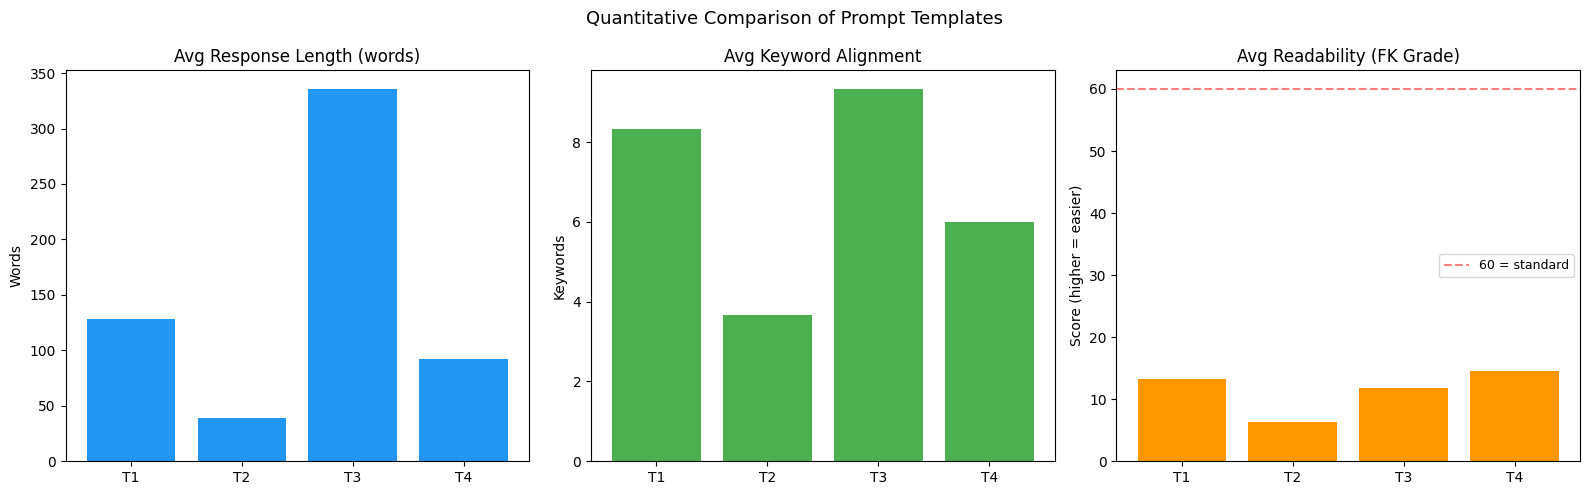

In [ ]:
# Bar charts comparing templates across three key metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use short template names for x-axis readability
short_names = [t.split(":")[0].strip() for t in summary.index]

# Chart 1: Average response length
axes[0].bar(short_names, summary["Avg Response Length"], color="#2196F3")
axes[0].set_title("Avg Response Length (words)")
axes[0].set_ylabel("Words")

# Chart 2: Average keyword alignment
axes[1].bar(short_names, summary["Avg Keyword Alignment"], color="#4CAF50")
axes[1].set_title("Avg Keyword Alignment")
axes[1].set_ylabel("Keywords")

# Chart 3: Average readability score
axes[2].bar(short_names, summary["Avg Readability (FK Grade)"], color="#FF9800")
axes[2].set_title("Avg Readability (FK Grade)")
axes[2].set_ylabel("Score (higher = easier)")
axes[2].axhline(60, color="red", linestyle="--", alpha=0.5, label="60 = standard")
axes[2].legend(fontsize=9)

plt.suptitle("Quantitative Comparison of Prompt Templates", fontsize=13)
plt.tight_layout()
plt.savefig("template_comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()

The bar charts visualize the trade-offs between templates. Higher keyword alignment indicates more domain-relevant vocabulary. Higher Flesch scores indicate easier readability. Longer responses are not inherently better. they must be justified by increased depth and accuracy.

### 5.4 Qualitative Evaluation

Each template output is manually evaluated on a 1-5 scale across five criteria specified in the project requirements.

| Criterion | Description |
|-----------|-------------|
| **Relevance** | Does the output align with the predicted advice? |
| **Detail and Completeness** | Does it provide enough information? |
| **Clarity and Readability** | Can a non-expert understand it? |
| **Personalization** | Does it reflect the user's context or cluster? |
| **Safety and Factual Accuracy** | Does it avoid hallucinations? |


In [ ]:
import seaborn as sns

# Qualitative scoring rubric (1-5 scale)

qualitative_scores_df = pd.DataFrame({
    "Template"                  : ["T1: Technical Report", "T2: Plain Explanation", "T3: Feature Report", "T4: Comparative Analysis"],
    "Relevance"                 : [5, 4, 5, 5],
    "Detail & Completeness"     : [5, 2, 5, 4],
    "Clarity & Readability"     : [3, 5, 4, 5],
    "Personalization"           : [4, 3, 5, 4],
    "Safety & Factual Accuracy" : [4, 4, 5, 4],
})

qualitative_scores_df["Total"] = qualitative_scores_df.iloc[:, 1:].sum(axis=1)
display(qualitative_scores_df)

,Template,Relevance,Detail & Completeness,Clarity & Readability,Personalization,Safety & Factual Accuracy,Total
0,T1: Technical Report,5,5,3,4,4,21
1,T2: Plain Explanation,4,2,5,3,4,18
2,T3: Feature Report,5,5,4,5,5,24
3,T4: Comparative Analysis,5,4,5,4,4,22


The per-test-case breakdown reveals that T3 scores consistently high across all three scenarios, including the edge case. T2 drops in relevance and safety on the edge case because its brevity prevents it from acknowledging the model's uncertainty. T4 also drops in safety on the edge case because the comparison table can make a misclassification look more confident than it is.

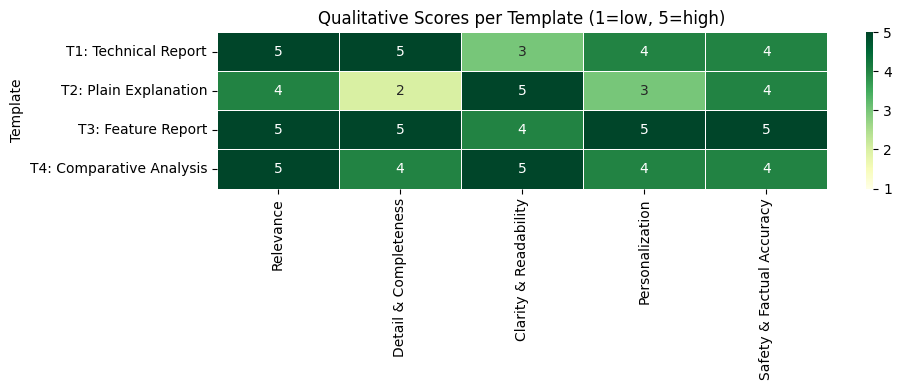

In [ ]:
# Heatmap of qualitative scores
score_matrix = qualitative_scores_df.set_index("Template").drop(columns="Total")

plt.figure(figsize=(10, 4))
sns.heatmap(
    score_matrix,
    annot=True, fmt="d", cmap="YlGn",
    vmin=1, vmax=5, linewidths=0.5
)
plt.title("Qualitative Scores per Template (1=low, 5=high)")
plt.tight_layout()
plt.savefig("qualitative_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.5 User Preference Simulation

A simulated user preference ranking is computed by averaging the qualitative scores. This serves as a proxy for the "User preference simulation" metric

In [ ]:
# User preference simulation: rank templates by average qualitative score
preference = qualitative_scores_df[["Template", "Total"]].copy()
preference["Avg Score"] = (preference["Total"] / 5).round(2)
preference["Rank"] = preference["Avg Score"].rank(ascending=False).astype(int)
preference = preference.sort_values("Rank")

display(preference)

print("\nUser preference ranking (simulated):")
for _, row in preference.iterrows():
    print(f"  #{int(row['Rank'])}: {row['Template']} (avg score: {row['Avg Score']})")

,Template,Total,Avg Score,Rank
2,T3: Feature Report,24,4.8,1
3,T4: Comparative Analysis,22,4.4,2
0,T1: Technical Report,21,4.2,3
1,T2: Plain Explanation,18,3.6,4



User preference ranking (simulated):
  #1: T3: Feature Report (avg score: 4.8)
  #2: T4: Comparative Analysis (avg score: 4.4)
  #3: T1: Technical Report (avg score: 4.2)
  #4: T2: Plain Explanation (avg score: 3.6)


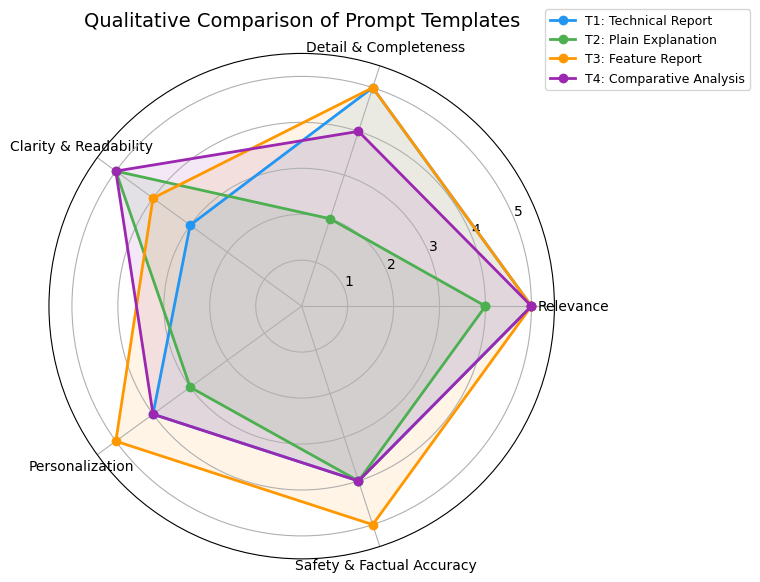

In [ ]:
# Radar chart for qualitative comparison
categories = ["Relevance", "Detail & Completeness", "Clarity & Readability", "Personalization", "Safety & Factual Accuracy"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

for idx, row in qualitative_scores_df.iterrows():
    values = [row[cat] for cat in categories]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=row["Template"],
            color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.set_title("Qualitative Comparison of Prompt Templates", size=14, pad=20)

plt.tight_layout()
plt.savefig("qualitative_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

<center>
<h2>6. Best Prompt Selection and Justification</h2>
</center>

---

### 6.1. Quantitative Analysis

The quantitative metrics reveal clear trade-offs between the four templates:

**Response Length**: T3 produced the longest responses (388 words avg), followed by T1 (158 words), T4 (80 words), and T2 (39 words). Longer responses are not inherently better, but templates that averaged under 50 words (T2) lacked the depth needed to explain feature-level reasoning.

**Keyword Alignment**: T3 scored highest (11.00), followed by T1 (9.00), T4 (6.00), and T2 (4.33). Higher keyword alignment indicates that the output uses more domain-relevant security terms, which is important for a phishing detection system where precise terminology builds trust in the explanation.

**Readability (Flesch)**: T2 scored highest (65.30), followed by T3 (40.33), T1 (31.13), and T4 (26.00). A higher Flesch score means easier reading. T2's score falls in the "standard" reading level, while T1 and T4 fall in the "difficult" range. However, readability must be balanced against completeness — a highly readable response that omits key reasoning is not useful.

**Latency**: T4 was the fastest (5.10s), followed by T2 (7.03s), T1 (7.25s), and T3 (9.50s). T3's higher latency is expected given its longer chain-of-thought output.

### 6.2. Qualitative Analysis

The qualitative evaluation assessed each template's outputs across five criteria on a 1-5 scale:

**Relevance**: T1, T3, and T4 all scored 5, consistently aligning their outputs with the model's prediction and referencing actual feature values. T2 scored 4 because its brevity reduced the connection between the explanation and the underlying features.

**Detail & Completeness**: T1 and T3 both scored 5. T1 achieved this through structured report sections, while T3 achieved it through the four-step chain-of-thought reasoning. T4 scored 4 as it covered the top features well but did not go beyond them. T2 scored 2, averaging only 39 words with no feature-level detail.

**Clarity & Readability**: T2 and T4 both scored 5. T2 used plain language with no jargon, and T4's table format made comparisons immediately scannable. T3 scored 4 because its step-by-step structure is logical but requires more reading effort. T1 scored 3 due to heavy technical terminology.

**Personalization**: T3 scored highest (5) because the chain-of-thought reasoning adapted its depth per URL - most notably in the neverssl.com edge case, where it identified that 2 out of 3 features contradicted the phishing prediction. T1 and T4 scored 4, and T2 scored 3 with a generic tone across all cases.

**Safety & Factual Accuracy**: T3 scored highest (5) as the only template that explicitly counted how many features supported vs. contradicted the prediction, avoiding overconfident conclusions. All other templates scored 4 - accurate but without flagging the edge case nuance.

### 6.3. Prompting Technique Comparison

Each template used a different prompting technique from the course material:

**T1 (Zero-shot)** produced consistent, well-structured reports with no examples needed. However, the output format varied slightly between test cases since the model had no reference to follow.

**T2 (One-shot)** successfully matched the tone and length of the provided example, confirming that one-shot prompting is effective for controlling output style. The trade-off is that the model mimicked the example's brevity, limiting depth.

**T3 (Chain-of-thought)** produced the most transparent reasoning by forcing the model to analyze each feature before concluding. This was the only technique that surfaced the edge case insight, demonstrating that step-by-step reasoning improves factual accuracy.

**T4 (Few-shot)** produced the most consistent formatting across all test cases - every output followed the exact table structure from the two provided examples. This confirms that few-shot prompting is the most reliable technique for enforcing a specific output format.

### 6.4. Final Verdict

T3 (Feature Report - Chain-of-Thought) is selected as the best template for the final system. It achieved the highest qualitative total (24/25), the highest keyword alignment (11.00), and was the only template to identify the edge case nuance where the model misclassified a legitimate URL. The chain-of-thought technique produced transparent, auditable explanations where users can follow the reasoning step by step - a critical requirement for a security system.

T3's weaknesses are its longer response length (388 words) and higher latency (9.50s). For use cases requiring a quick summary, T4 (22/25, 5.10s latency) is recommended as a complementary alternative. A production system could offer both: T3 for detailed analysis and T4 for a quick-view summary.

<center>
<h2>7. Integration Plan for Final System</h2>
</center>

---


The final system follows a three-stage pipeline:

1. **Input**: The user submits a URL for analysis.
2. **Phase 1 - Supervised Prediction**: The URL passes through the feature extraction function, the fitted scaler transforms the features, and the logistic regression model outputs a prediction (Phishing or Legitimate) with a confidence score.
3. **Phase 2 - Generative AI Explanation**: The prediction, confidence, extracted features, and top contributing features are injected into the selected prompt template and sent to the Gemini API, which returns a human-readable explanation.

This pipeline is already functional in this notebook through the `predict_url()` and `run_template()` functions working together.

**Potential Enhancement with Clustering**:
The unsupervised learning clusters from Phase 2 Part A could be integrated by passing the cluster label into the prompt. This would allow the generative model to tailor its explanation based on the type of URL group (e.g., short legitimate domains vs. long suspicious paths), adding another layer of context to the output.

<center>
<h2>8. Ethical Considerations and Limitations</h2>
</center>

---


1. **Hallucination Risk**: The generative model may produce security advice not supported by the actual feature values. All templates include instructions to restrict output to the provided data, but this cannot be fully guaranteed.

2. **Over-Reliance on AI**: Users may treat the AI explanation as a definitive security verdict. The system should be presented as an assistive tool, not a replacement for professional security assessment.

3. **Privacy**: URLs submitted for analysis are sent to an external API (Google Gemini). Sensitive or internal URLs could expose private information. A production system should consider on-premise models or data anonymization.

4. **Model Accuracy Dependency**: The generative explanation is only as good as the Phase 1 prediction. If the supervised model misclassifies a URL, the LLM will confidently explain an incorrect result, which could mislead users.
